# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import torch
from torch import nn
from torch import optim
import time

import tltorch
from Utils.Reshape import reshape

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Synthetic Data

device is set to : cuda


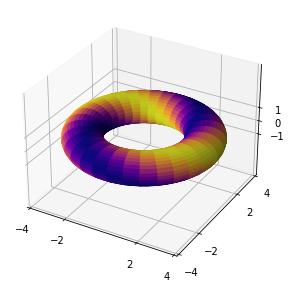

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

def generate_gaussian_tensor(n_samples, size):
    mean = 0
    variance = 5
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size, size))
    tensor = torch.from_numpy(tensor).float()

    (theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, size),
                           np.linspace(0, 2 * np.pi, size))
    
    Weight = torch.zeros((3, size, size))
    Weight[0,:,:] = torch.from_numpy((3 + np.cos(phi)) * np.cos(theta)).float()
    Weight[1,:,:] = torch.from_numpy((3 + np.cos(phi)) * np.sin(theta)).float()
    Weight[2,:,:] = torch.from_numpy(np.sin(phi)).float()

    output  = torch.einsum('abc, ocb->ao', tensor, Weight)


    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size, size))
    noise = torch.from_numpy(noise).float()

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 1000
size = 64

samples, y, W, x = generate_gaussian_tensor(n_samples, size)


(theta, phi) = np.meshgrid(np.linspace(0, 2 * np.pi, size),
                           np.linspace(0, 2 * np.pi, size))
def fun(t, f): return (np.cos(f + 2 * t) + 1) / 2

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W[0,:,:].cpu(), W[1,:,:].cpu(), W[2,:,:].cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

# Basic Linear Model

Epoch [1/10000], Loss: 67841.546875
Epoch [101/10000], Loss: 55571.56640625
Epoch [201/10000], Loss: 45613.4921875
Epoch [301/10000], Loss: 37460.296875
Epoch [401/10000], Loss: 30736.779296875
Epoch [501/10000], Loss: 25167.40234375
Epoch [601/10000], Loss: 20543.203125
Epoch [701/10000], Loss: 16701.724609375
Epoch [801/10000], Loss: 13513.84765625
Epoch [901/10000], Loss: 10874.791015625
Epoch [1001/10000], Loss: 8697.9072265625
Epoch [1101/10000], Loss: 6910.43212890625
Epoch [1201/10000], Loss: 5450.5927734375
Epoch [1301/10000], Loss: 4265.607421875
Epoch [1401/10000], Loss: 3310.24853515625
Epoch [1501/10000], Loss: 2545.752197265625
Epoch [1601/10000], Loss: 1938.9559326171875
Epoch [1701/10000], Loss: 1461.57763671875
Epoch [1801/10000], Loss: 1089.6031494140625
Epoch [1901/10000], Loss: 802.753173828125
Epoch [2001/10000], Loss: 584.0104370117188
Epoch [2101/10000], Loss: 419.20391845703125
Epoch [2201/10000], Loss: 296.6337585449219
Epoch [2301/10000], Loss: 206.734664916992

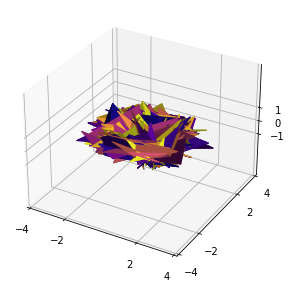

In [5]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size*size, out_features=3, bias=False)
    def forward(self, x):
        x = x.reshape(-1,size*size)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()
    
    if epoch%100 ==0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

W_fc = model.fc.weight.reshape(-1,size,size)

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W_fc[0,:,:].detach().cpu(), W_fc[1,:,:].detach().cpu(), W_fc[2,:,:].detach().cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

# Basic TRL Model

Epoch [1/1000], Loss: 82464.7265625
Epoch [101/1000], Loss: 21279.08203125
Epoch [201/1000], Loss: 3803.491943359375
Epoch [301/1000], Loss: 1199.4559326171875
Epoch [401/1000], Loss: 334.8523864746094
Epoch [501/1000], Loss: 100.91072082519531
Epoch [601/1000], Loss: 32.78138732910156
Epoch [701/1000], Loss: 10.781461715698242
Epoch [801/1000], Loss: 3.4893577098846436
Epoch [901/1000], Loss: 1.1013407707214355


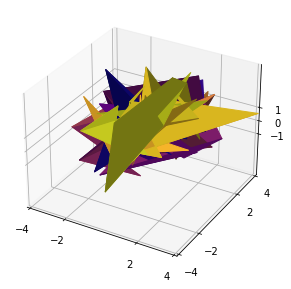

In [6]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64,64), rank=(64,64,3), output_shape=(3), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)


# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 1000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()
    
    if epoch%100 ==0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

W_trl = model.trl.weight.to_tensor()

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W_trl[0,:,:].detach().cpu(), W_trl[1,:,:].detach().cpu(), W_trl[2,:,:].detach().cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

# Basic Attached Model

In [133]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,2,2,1,32,32), rank=(1,2,2,1,32,32,3), output_shape=(3), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)


model.trl.weight.to_tensor().reshape(3,64,64).shape

torch.Size([3, 64, 64])

Epoch [1/5], Loss: 90706.6640625
Epoch [2/5], Loss: 89790.015625
Epoch [3/5], Loss: 88899.75
Epoch [4/5], Loss: 88035.59375
Epoch [5/5], Loss: 87197.21875


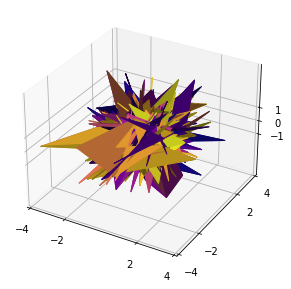

In [7]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,2,2,1,32,32), rank=(1,2,2,1,32,32,3), output_shape=(3), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)


# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

W_attached = model.trl.weight.to_tensor().reshape(3,64,64)

fig = plt.figure(num=1, clear=True)
ax = fig.add_subplot(1, 1, 1, projection='3d')

dplot = ax.plot_surface(W_attached[0,:,:].detach().cpu(), W_attached[1,:,:].detach().cpu(), W_attached[2,:,:].detach().cpu(), facecolors=cm.get_cmap('plasma')(fun(theta, phi)))
ax.set(xlim = [-4, 4],
       ylim = [-4, 4],
       zlim = [-4, 4],
       xticks = [-4, -2, 2, 4],
       yticks = [-4, -2, 2, 4],
       zticks = [-1, 0, 1])

fig.tight_layout()
plt.show()

Epoch [1/5], Loss: 6549921.0
Epoch [2/5], Loss: 6521711.5
Epoch [3/5], Loss: 6494307.0
Epoch [4/5], Loss: 6467566.0
Epoch [5/5], Loss: 6441310.5
Done Training


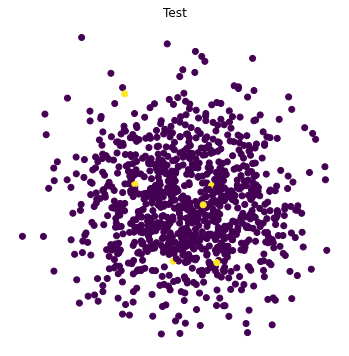

In [78]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Compressed Model

Epoch [1/5], Loss: 6938117.0
Epoch [2/5], Loss: 6864162.5
Epoch [3/5], Loss: 6792626.5
Epoch [4/5], Loss: 6723414.0
Epoch [5/5], Loss: 6656418.0
Done Training


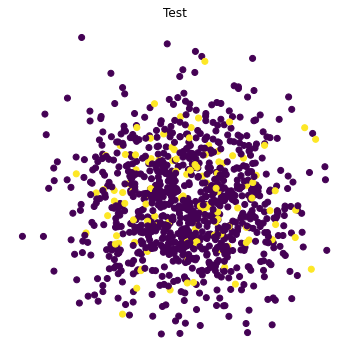

In [79]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()